## Classification Model with torch.nn.Module

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt



In [5]:
## Load FashionMNIST
transform=transforms.ToTensor()

dataset=datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Image 
X=dataset.data.float()/255.0

# Labels
y=dataset.targets

# Flatten images
X=X.view(-1, 784)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

Dataset Shape: torch.Size([60000, 784])
Labels Shape: torch.Size([60000])


In [6]:
## Train Validation Split
X_train, X_temp, y_train, y_temp=train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test=train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("\nTrain:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: torch.Size([48000, 784])
Validation: torch.Size([6000, 784])
Test: torch.Size([6000, 784])


In [10]:
# Model

class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1=nn.Linear(784, 256)
        self.fc2=nn.Linear(256, 128)
        self.fc3=nn.Linear(128, 10)
        
        
    def forward(self, x):
        x=torch.relu(self.fc1(x))
        x=torch.relu(self.fc2(x))
        x=self.fc3(x)
        
        return x
    

model=FashionClassifier()

print("The Model:",model)


The Model: FashionClassifier(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:
## Loss & Optimizer
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(
    model.parameters(),
    lr=0.001
)

In [12]:
### Training

# history
train_losses=[]
val_losses=[]

train_accs=[]
val_accs=[]

grad_norms=[]

epochs=50

for epoch in range(epochs):
    model.train()
    
    outputs=model(X_train)
    
    train_loss=criterion(
        outputs, y_train
    )
    
    optimizer.zero_grad()
    
    train_loss.backward()
    
    grad_norm=(
        model.fc1.weight.grad.norm().item()
    )
    
    optimizer.step()
    
    train_preds=torch.argmax(
        outputs, dim=1
    )
    train_acc=(
        (train_preds==y_train)
        .float()
        .mean()
        .item()
    )
    
    # validation
    model.eval()
    
    with torch.no_grad():
        val_outputs=model(X_val)
        
        val_loss=criterion(
            val_outputs, y_val
        )
        val_preds=torch.argmax(
            val_outputs, dim=1
        )
        
        val_acc=(
            (val_preds==y_val)
            .float()
            .mean()
            .item()
        )
    

    # SAVE HISTORY

    train_losses.append(
        train_loss.item()
    )

    val_losses.append(
        val_loss.item()
    )

    train_accs.append(
        train_acc
    )

    val_accs.append(
        val_acc
    )

    grad_norms.append(
        grad_norm
    )
    
    if epoch % 5 == 0:
        print(
            f"Epoch {epoch:2d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )
    

Epoch  0 | Train Loss: 2.3029 | Val Loss: 2.2354 | Train Acc: 0.1208 | Val Acc: 0.2137
Epoch  5 | Train Loss: 1.9119 | Val Loss: 1.8076 | Train Acc: 0.5329 | Val Acc: 0.5967
Epoch 10 | Train Loss: 1.3746 | Val Loss: 1.2746 | Train Acc: 0.6565 | Val Acc: 0.6642
Epoch 15 | Train Loss: 0.9703 | Val Loss: 0.9248 | Train Acc: 0.6750 | Val Acc: 0.6805
Epoch 20 | Train Loss: 0.7878 | Val Loss: 0.7740 | Train Acc: 0.7049 | Val Acc: 0.7060
Epoch 25 | Train Loss: 0.7077 | Val Loss: 0.7037 | Train Acc: 0.7359 | Val Acc: 0.7367
Epoch 30 | Train Loss: 0.6534 | Val Loss: 0.6479 | Train Acc: 0.7600 | Val Acc: 0.7650
Epoch 35 | Train Loss: 0.6018 | Val Loss: 0.5994 | Train Acc: 0.7886 | Val Acc: 0.7850
Epoch 40 | Train Loss: 0.5638 | Val Loss: 0.5603 | Train Acc: 0.8034 | Val Acc: 0.8012
Epoch 45 | Train Loss: 0.5347 | Val Loss: 0.5327 | Train Acc: 0.8140 | Val Acc: 0.8167


In [13]:
## Test Set Evaluation
model.eval()
with torch.no_grad():
    test_outputs=model(X_test)
    test_preds=torch.argmax(
        test_outputs, dim=1
    )
    
    test_acc=(
        (test_preds==y_test)
        .float()
        .mean()
        .item()
    )

print("\nFinal Test Accuracy:", test_acc)


Final Test Accuracy: 0.809166669845581


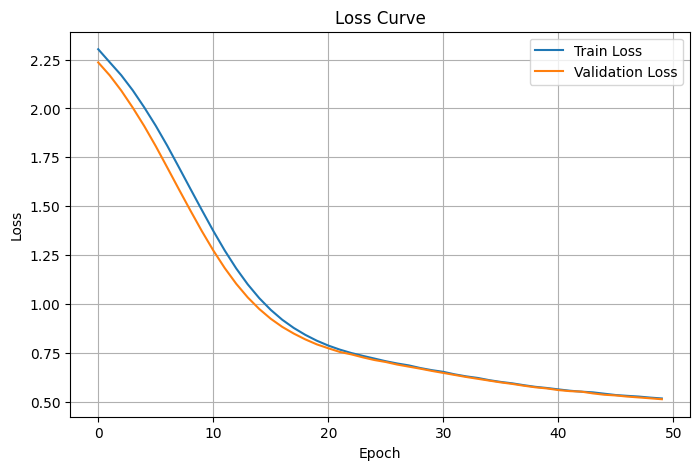

In [14]:
## Loss Curve

plt.figure(figsize=(8,5))
plt.plot(
    train_losses, label="Train Loss"
)
plt.plot(
    val_losses, 
    label="Validation Loss"
)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

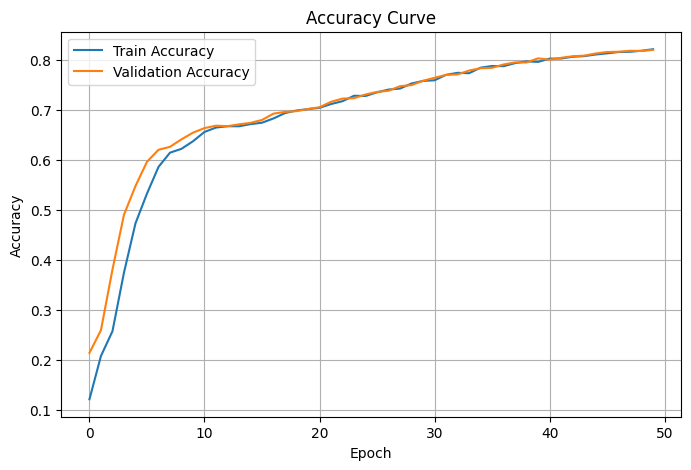

In [15]:
## Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(
    train_accs, label="Train Accuracy"
)
plt.plot(
    val_accs, label="Validation Accuracy"
)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

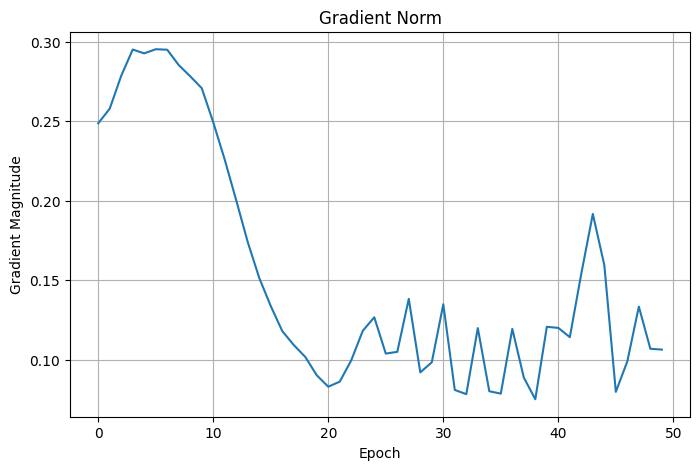

In [16]:
## Gradient Curve
plt.figure(figsize=(8, 5))
plt.plot(grad_norms)
plt.title("Gradient Norm")
plt.xlabel("Epoch")
plt.ylabel("Gradient Magnitude")

plt.grid()
plt.show()